# Normal Distribution

The **Normal (Gaussian) distribution** is the most widely used continuous distribution. It arises naturally from the Central Limit Theorem — sums of many independent random variables converge to it regardless of the original distribution.

| Property | Value |
|---|---|
| **Parameters** | μ (location), σ (scale, σ > 0) |
| **Support** | (−∞, +∞) |
| **PDF** | f(x) = (1/σ√2π) exp(−(x−μ)²/2σ²) |
| **Mean** | μ |
| **Median** | μ |
| **Mode** | μ |
| **Std Dev** | σ |
| **Skewness** | 0 (symmetric) |
| **Kurtosis** | 3 (mesokurtic) |
| **Parameter estimation** | μ̂ = x̄, σ̂ = s (sample mean and std) |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import SVG, display
import warnings
warnings.filterwarnings('ignore')

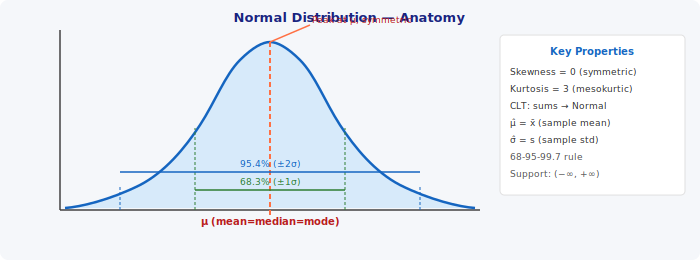

In [2]:
_svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="700" height="260"
     font-family="'Segoe UI', Arial, sans-serif">
  <rect width="700" height="260" fill="#F5F7FA" rx="8"/>
  <text x="350" y="22" text-anchor="middle" font-size="13" font-weight="bold"
        fill="#1A237E">Normal Distribution — Anatomy</text>

  <!-- Axes -->
  <line x1="60" y1="210" x2="480" y2="210" stroke="#424242" stroke-width="1.5"/>
  <line x1="60" y1="30"  x2="60"  y2="210" stroke="#424242" stroke-width="1.5"/>

  <!-- Bell curve (μ=270, peak at y=50) -->
  <path d="M 65,208 C 80,207 110,200 140,185 C 165,172 185,148 200,125
           C 215,102 225,75 240,60 C 253,47 263,42 270,42
           C 277,42 287,47 300,60 C 315,75 325,102 340,125
           C 355,148 375,172 400,185 C 430,200 460,207 475,208"
        fill="#BBDEFB" opacity="0.5"/>
  <path d="M 65,208 C 80,207 110,200 140,185 C 165,172 185,148 200,125
           C 215,102 225,75 240,60 C 253,47 263,42 270,42
           C 277,42 287,47 300,60 C 315,75 325,102 340,125
           C 355,148 375,172 400,185 C 430,200 460,207 475,208"
        fill="none" stroke="#1565C0" stroke-width="2.5"/>

  <!-- μ line -->
  <line x1="270" y1="42" x2="270" y2="215" stroke="#FF7043" stroke-width="2" stroke-dasharray="5,3"/>
  <text x="270" y="225" text-anchor="middle" font-size="10" fill="#B71C1C" font-weight="bold">μ (mean=median=mode)</text>

  <!-- ±1σ -->
  <line x1="195" y1="210" x2="195" y2="128" stroke="#2E7D32" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="345" y1="210" x2="345" y2="128" stroke="#2E7D32" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="195" y1="190" x2="345" y2="190" stroke="#2E7D32" stroke-width="1.5"/>
  <text x="270" y="185" text-anchor="middle" font-size="9" fill="#2E7D32">68.3% (±1σ)</text>

  <!-- ±2σ -->
  <line x1="120" y1="210" x2="120" y2="186" stroke="#1565C0" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="420" y1="210" x2="420" y2="186" stroke="#1565C0" stroke-width="1" stroke-dasharray="3,2"/>
  <line x1="120" y1="172" x2="420" y2="172" stroke="#1565C0" stroke-width="1.5"/>
  <text x="270" y="167" text-anchor="middle" font-size="9" fill="#1565C0">95.4% (±2σ)</text>

  <!-- Symmetry annotation -->
  <line x1="270" y1="42" x2="310" y2="25" stroke="#FF7043" stroke-width="1.5"/>
  <text x="312" y="23" font-size="9" fill="#B71C1C">Peak at μ, symmetric</text>

  <!-- Properties box -->
  <rect x="500" y="35" width="185" height="160" fill="white" stroke="#E0E0E0" rx="4"/>
  <text x="592" y="55" text-anchor="middle" font-size="10" font-weight="bold" fill="#1565C0">Key Properties</text>
  <text x="510" y="75"  font-size="9" fill="#333">Skewness = 0 (symmetric)</text>
  <text x="510" y="92"  font-size="9" fill="#333">Kurtosis = 3 (mesokurtic)</text>
  <text x="510" y="109" font-size="9" fill="#333">CLT: sums → Normal</text>
  <text x="510" y="126" font-size="9" fill="#333">μ̂ = x̄  (sample mean)</text>
  <text x="510" y="143" font-size="9" fill="#333">σ̂ = s   (sample std)</text>
  <text x="510" y="160" font-size="9" fill="#555">68-95-99.7 rule</text>
  <text x="510" y="177" font-size="9" fill="#555">Support: (−∞, +∞)</text>
</svg>
"""
display(SVG(_svg))

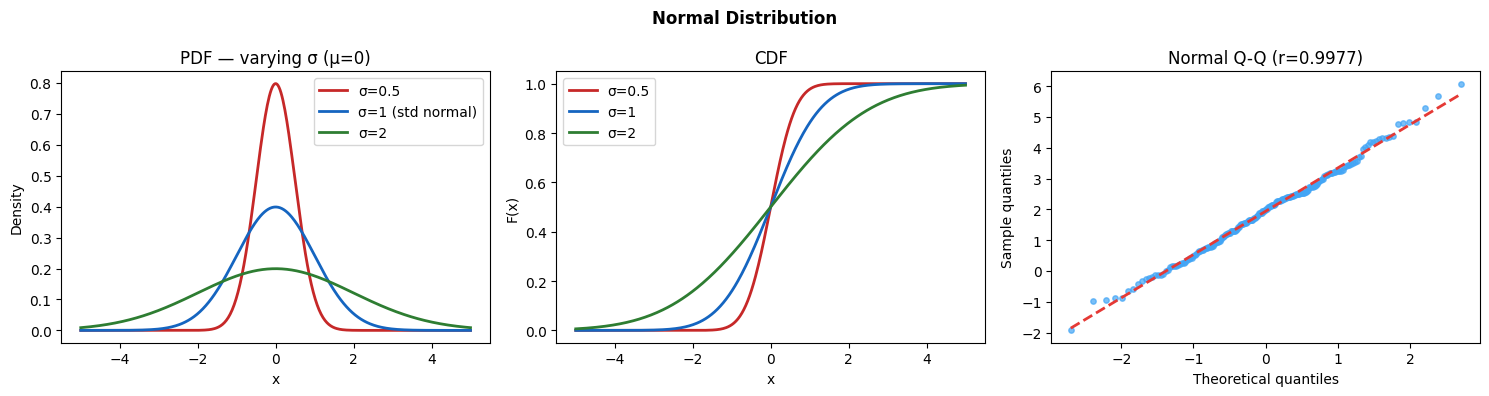

68-95-99.7 rule (standard normal):
  P(|X| ≤ 1σ) = 68.27%  (rule of thumb: 68.27%)
  P(|X| ≤ 2σ) = 95.45%  (rule of thumb: 95.45%)
  P(|X| ≤ 3σ) = 99.73%  (rule of thumb: 99.73%)


In [3]:
x = np.linspace(-5, 5, 400)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Normal Distribution', fontsize=12, fontweight='bold')

# PDF — vary σ
for sigma, color, label in [(0.5, '#C62828', 'σ=0.5'), (1, '#1565C0', 'σ=1 (std normal)'), (2, '#2E7D32', 'σ=2')]:
    axes[0].plot(x, stats.norm(0, sigma).pdf(x), color=color, linewidth=2, label=label)
axes[0].set_title('PDF — varying σ (μ=0)')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend()

# CDF
for sigma, color, label in [(0.5, '#C62828', 'σ=0.5'), (1, '#1565C0', 'σ=1'), (2, '#2E7D32', 'σ=2')]:
    axes[1].plot(x, stats.norm(0, sigma).cdf(x), color=color, linewidth=2, label=label)
axes[1].set_title('CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend()

# Q-Q plot
np.random.seed(42)
sample = np.random.normal(2, 1.5, 200)
(osm, osr), (slope, intercept, r) = stats.probplot(sample, dist='norm')
axes[2].scatter(osm, osr, color='#42A5F5', s=15, alpha=0.7)
axes[2].plot([min(osm), max(osm)], [slope*min(osm)+intercept, slope*max(osm)+intercept],
             color='#E53935', linewidth=2, linestyle='--')
axes[2].set_title(f'Normal Q-Q (r={r:.4f})')
axes[2].set_xlabel('Theoretical quantiles'); axes[2].set_ylabel('Sample quantiles')

plt.tight_layout()
plt.show()

# 68-95-99.7 rule
print("68-95-99.7 rule (standard normal):")
for k, pct in [(1, 68.27), (2, 95.45), (3, 99.73)]:
    actual = (stats.norm.cdf(k) - stats.norm.cdf(-k)) * 100
    print(f"  P(|X| ≤ {k}σ) = {actual:.2f}%  (rule of thumb: {pct}%)")

## Key Takeaways

| | |
|---|---|
| **Shape** | Symmetric bell curve — skewness=0, kurtosis=3 |
| **CLT** | Sample means of any distribution converge to Normal as n→∞ |
| **Estimation** | μ̂ = x̄ (MLE = MOM); σ̂ = s |
| **68-95-99.7** | 68% within ±1σ, 95% within ±2σ, 99.7% within ±3σ |
| **Standard form** | Z = (X−μ)/σ ~ N(0,1) — enables all probability table lookups |
| **Outlier check** | \|Z\| > 3 is unusual (probability 0.3%) |
| **Q-Q plot** | Points on the diagonal → data is normally distributed |